In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/Diabetes.zip'

**Loading Dataset**

In [ ]:
import zipfile
import os
extraction_dir = '/content/drive/MyDrive/Diabetes_Extracted_Data'
os.makedirs(extraction_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)
    print(f"Files extracted to {extraction_dir}")
extracted_files = os.listdir(extraction_dir)
print("Extracted Files:", extracted_files)

Files extracted to /content/drive/MyDrive/Diabetes_Extracted_Data
Extracted Files: ['diabetes.csv']


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<Axes: xlabel='Outcome', ylabel='count'>

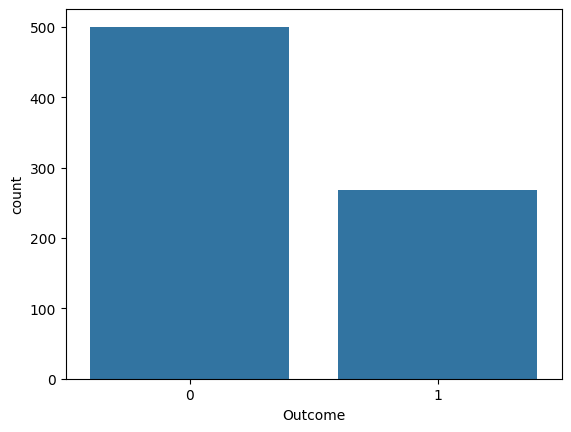

In [ ]:
import seaborn as sns
sns.countplot(x='Outcome', data=df)

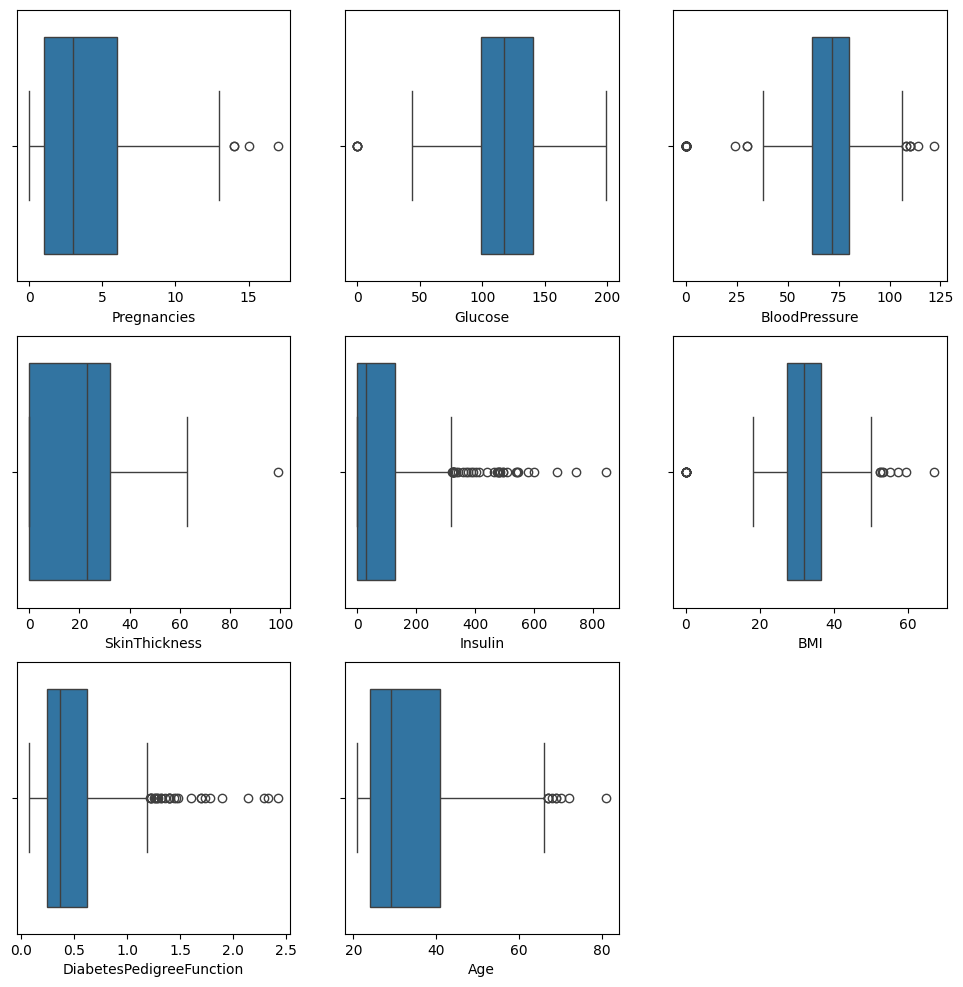

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
for i, col in enumerate(['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']):
    plt.subplot(3,3,i+1)
    sns.boxplot(x = col, data = df)
plt.show()

# **`Handling Outliers`**

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if col != 'Outcome':
        df = remove_outliers(df, col)

print("Outliers removed!")
print(f"Dataset Shape after outlier removal: {df.shape}")


Outliers removed!
Dataset Shape after outlier removal: (636, 9)



Visualizing Correlations...


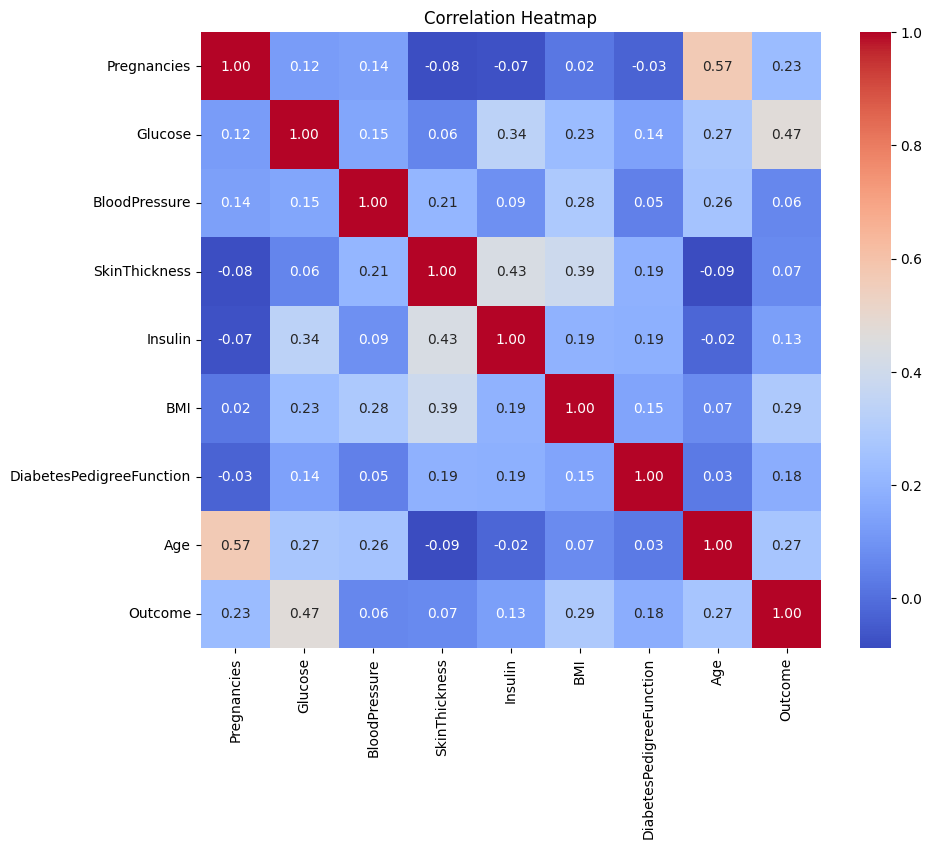

In [ ]:
print("\nVisualizing Correlations...")
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=['Outcome'])
y = df['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Features after scaling:")
print(X_scaled.head())

Features after scaling:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.681426  1.005403      -0.000696       0.936596 -0.826197  0.256438   
1    -0.857590 -1.168963      -0.532036       0.542370 -0.826197 -0.840893   
2     1.297032  2.213384      -0.709149      -1.363054 -0.826197 -1.358207   
3    -0.857590 -1.030908      -0.532036       0.148145  0.299065 -0.605751   
4     0.373623 -0.099037       0.176417      -1.363054 -0.826197 -0.997655   

   DiabetesPedigreeFunction       Age  
0                  0.819791  1.604688  
1                 -0.307223 -0.143041  
2                  1.003543 -0.051055  
3                 -1.058566 -1.062898  
4                 -0.919731 -0.235026  


In [ ]:
from sklearn.model_selection import train_test_split
print("\nSplitting Dataset into Training, Testing, and Validation Sets...")
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_test, X_val, Y_test, Y_val = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
print("Data Splitting Complete!")
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")
print(f"Validation Set Shape: {X_val.shape}")



Splitting Dataset into Training, Testing, and Validation Sets...
Data Splitting Complete!
Training Set Shape: (381, 8)
Testing Set Shape: (127, 8)
Validation Set Shape: (128, 8)


# **Training SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
print("\nTraining the SVM model...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, Y_train)
print("Model Training Complete!")




Training the SVM model...
Model Training Complete!


**Model** **Evaluation**


Evaluating on the Validation Set...
F1 Score on Validation Set: 0.5455
AUC-ROC Score on Validation Set: 0.7807

Evaluating on the Test Set...
F1 Score on Test Set: 0.4839
AUC-ROC Score on Test Set: 0.7321

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        90
           1       0.60      0.41      0.48        37

    accuracy                           0.75       127
   macro avg       0.69      0.65      0.66       127
weighted avg       0.73      0.75      0.73       127


Confusion Matrix (Test Set):
[[80 10]
 [22 15]]


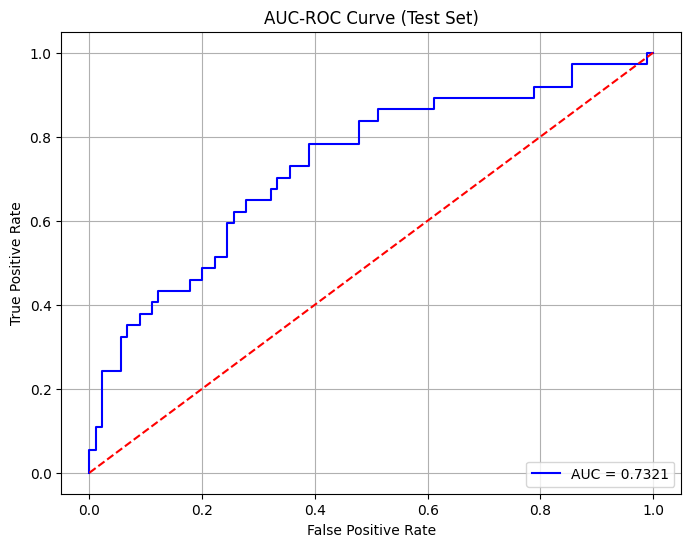

In [ ]:
# Evaluate on the validation set
print("\nEvaluating on the Validation Set...")
Y_val_pred = svm_model.predict(X_val)
Y_val_proba = svm_model.predict_proba(X_val)[:, 1]
f1_val = f1_score(Y_val, Y_val_pred)
print(f"F1 Score on Validation Set: {f1_val:.4f}")
auc_val = roc_auc_score(Y_val, Y_val_proba)
print(f"AUC-ROC Score on Validation Set: {auc_val:.4f}")
# Evaluate on the Test Set
print("\nEvaluating on the Test Set...")
Y_test_pred = svm_model.predict(X_test)
Y_test_proba = svm_model.predict_proba(X_test)[:, 1]
f1_test = f1_score(Y_test, Y_test_pred)
print(f"F1 Score on Test Set: {f1_test:.4f}")
auc_test = roc_auc_score(Y_test, Y_test_proba)
print(f"AUC-ROC Score on Test Set: {auc_test:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(Y_test, Y_test_pred))

print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(Y_test, Y_test_pred))
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid()
plt.show()
